# Classical Baselines: Exponential Smoothing and SARIMA

Builds and compares classical statistical forecasting models on the synthetic daily-orders dataset explored in notebook 01. The goal is to establish a strong baseline error rate before introducing more flexible models (Prophet, ML methods) in later work.

**What this notebook covers**

1. Simple Exponential Smoothing from scratch to ground the intuition behind the smoothing parameter.
2. Holt-Winters (ETS) baseline with weekly seasonality, scored on a 56-day holdout.
3. Grid search over additive vs multiplicative trend and seasonal components.
4. Interpretation of the fitted smoothing parameters.
5. Auto-selected ARIMA via `pmdarima.auto_arima`.
6. A manually specified SARIMA(1,1,1)(1,1,1,7) and a reproducibility check against `auto_arima`.

**Headline result**: a manual SARIMA(1,1,1)(1,1,1,7) and the best Holt-Winters configuration both achieve roughly 9–10% MAPE on the 56-day holdout, better than the model `auto_arima` selects on this dataset (aprox 22% MAPE).

## 1. Simple Exponential Smoothing from scratch

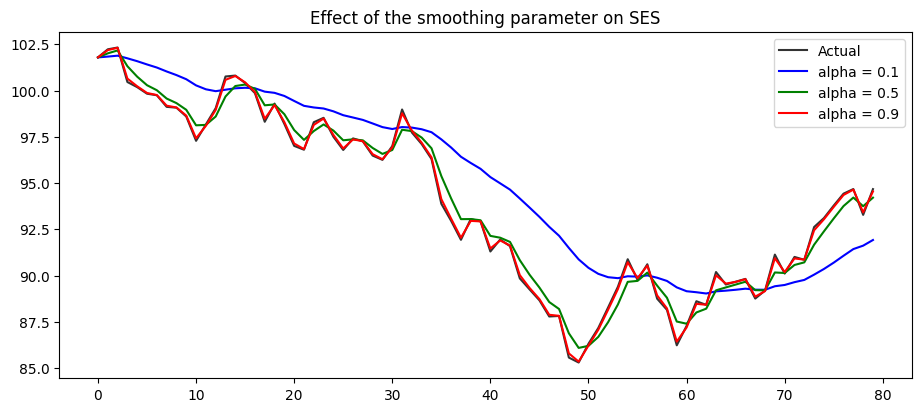

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(3)
data = 100 + np.cumsum(np.random.randn(80))

def ses(values, alpha):
    out = [values[0]]
    for x in values[1:]:
        out.append(alpha * x + (1 - alpha) * out[-1])
    return np.array(out)

plt.figure(figsize=(11, 4.5))
plt.plot(data, color="black", label="Actual", alpha=0.8)
for alpha, color in [(0.1, "blue"), (0.5, "green"), (0.9, "red")]:
    plt.plot(ses(data, alpha), color=color, label=f"alpha = {alpha}")
plt.legend()
plt.title("Effect of the smoothing parameter on SES")
plt.show()

## 2. Load the data and define the holdout

We use the same synthetic order log as notebook 01, with the last 56 days (8 weeks) reserved for evaluation.

In [2]:
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

df = pd.read_csv("../files/synthetic_orders.csv", parse_dates=["date"]).set_index("date")
y = df["orders_total"]

train = y.iloc[:-56]
test = y.iloc[-56:]
print(f"train: {len(train)} days,  test: {len(test)} days")

train: 675 days,  test: 56 days


## 3. Holt-Winters baseline

Holt-Winters extends SES with a trend term and a seasonal term. We start with additive trend and additive seasonality (period 7 for the weekly cycle) and score the forecast on the holdout with two metrics:

- **MAPE**: average percentage error per day. It treats every day equally.
- **WMAPE**: total absolute error scaled by total volume, it weights high-volume days more heavily.

In [3]:
hw_addadd = ExponentialSmoothing(
    train,
    seasonal_periods=7,
    trend="add",
    seasonal="add",
).fit()

forecast = hw_addadd.forecast(56)
forecast.head()

c:\Users\teste\Documents\ForecastingCurriculum\Exploring-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


2025-11-06    4640.669300
2025-11-07    4256.830390
2025-11-08    2923.985987
2025-11-09    2917.227780
2025-11-10    5527.973328
Freq: D, dtype: float64

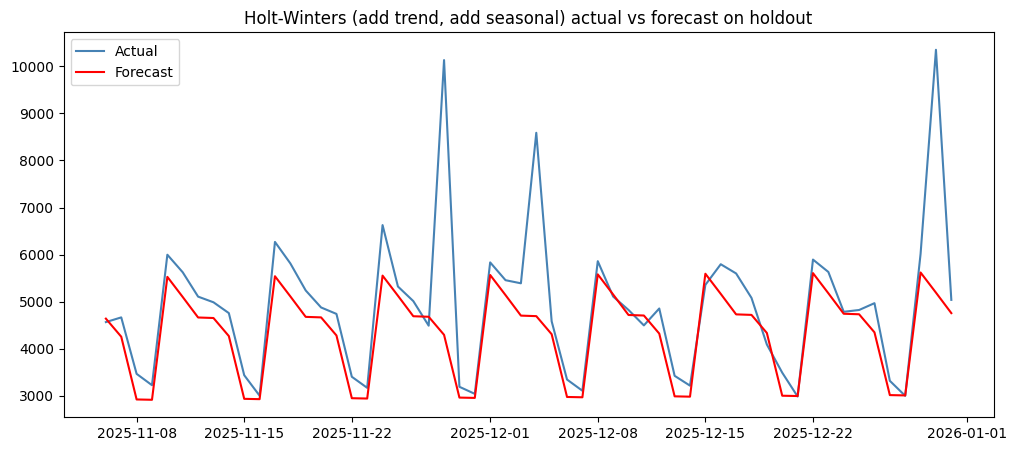

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(test.index, test, color="steelblue", label="Actual")
plt.plot(forecast.index, forecast, color="red", label="Forecast")
plt.legend()
plt.title("Holt-Winters (add trend, add seasonal) actual vs forecast on holdout")
plt.show()

In [5]:
def mape(actual, forecast):
    return np.mean(np.abs((actual - forecast) / actual)) * 100

def wmape(actual, forecast):
    return np.sum(np.abs(actual - forecast)) / np.sum(actual) * 100

print(f"MAPE:  {mape(test.values, forecast.values):.3f}%")
print(f"WMAPE: {wmape(test.values, forecast.values):.3f}%")

MAPE:  9.888%
WMAPE: 12.281%


## 4. Grid search over trend × seasonal configurations

Holt-Winters lets each of the trend and seasonal components be either additive (a constant offset is added to the level / each season) or multiplicative (the level / season is scaled).

In [6]:
results = []
for t in ("add", "mul"):
    for s in ("add", "mul"):
        try:
            model = ExponentialSmoothing(
                train,
                seasonal_periods=7,
                trend=t,
                seasonal=s,
            ).fit()
            fc = model.forecast(56)
            results.append({
                "trend": t,
                "seasonal": s,
                "train_mape": mape(train.values, model.fittedvalues.values),
                "test_mape": mape(test.values, fc.values),
                "status": "success",
            })
        except Exception as e:
            results.append({
                "trend": t,
                "seasonal": s,
                "train_mape": None,
                "test_mape": None,
                "status": f"error: {str(e)[:60]}",
            })

c:\Users\teste\Documents\ForecastingCurriculum\Exploring-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\teste\Documents\ForecastingCurriculum\Exploring-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\teste\Documents\ForecastingCurriculum\Exploring-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\teste\Documents\ForecastingCurriculum\Exploring-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:85: RuntimeWarning: overflow encountered in matmul
  return err.T @ err
c:\Users\teste\Documents\Forecast

In [7]:
df_results = pd.DataFrame(results)
df_results[df_results["status"] == "success"].sort_values("test_mape")

,trend,seasonal,train_mape,test_mape,status
1,add,mul,8.057321,9.311495,success
0,add,add,8.622631,9.888300,success
3,mul,mul,7.956345,10.161439,success
2,mul,add,8.597878,10.347398,success


**Result**

All four combinations fit successfully. The best test MAPE comes from **additive trend with multiplicative seasonality** (`trend="add"`, `seasonal="mul"`) at roughly 9.3%, a small but real improvement over additive/additive (aprox 9.9%). The multiplicative-trend variants achieve lower train MAPE but worse test MAPE.

The selected configuration is therefore **ETS(A, A, M)** additive errors, additive trend, multiplicative seasonality.

## 5. Smoothing parameters of the chosen model

Holt-Winters fits three smoothing parameters: alpha (level), Beta (trend), and Gamma (seasonal). Their magnitudes describe how reactive each component is to new observations.

In [8]:
params = model.params
print(f"alpha (level)    = {params['smoothing_level']:.3f}")
print(f"beta  (trend)    = {params['smoothing_trend']:.3f}")
print(f"gamma (seasonal) = {params['smoothing_seasonal']:.3f}")

alpha (level)    = 0.110
beta  (trend)    = 0.000
gamma (seasonal) = 0.000


**Interpretation**

- `alpha: 0.11` The level adapts slowly, long-run volume is treated as fairly stable.
- `beta: 0` The trend slope barely updates between periods, the model assumes a near constant long-term direction.
- `gamma: 0` The weekly seasonal shape is essentially fixed across the training window. 

## 6. ARIMA via `auto_arima`

`pmdarima.auto_arima` performs a stepwise search over ARIMA / SARIMA orders, picking the model that minimises an information criterion (AIC by default). It is a convenient default but only as good as its search space and selection criterion.

In [9]:
import pmdarima as pm

auto_model = pm.auto_arima(
    train,
    seasonal=True,
    m=7,
    trace=False,
    error_action="ignore",
    stepwise=True,
)
print(auto_model.summary())
forecast_auto = auto_model.predict(n_periods=56)

                                       SARIMAX Results                                        
Dep. Variable:                                      y   No. Observations:                  675
Model:             SARIMAX(0, 1, 1)x(0, 0, [1, 2], 7)   Log Likelihood               -5598.244
Date:                                Fri, 22 May 2026   AIC                          11206.488
Time:                                        11:59:28   BIC                          11229.054
Sample:                                    01-01-2024   HQIC                         11215.226
                                         - 11-05-2025                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.8011      3.330      0.541      0.589      -4.725       8.327
ma.

In [10]:
forecast_auto_vals = np.asarray(forecast_auto)
print(f"Auto-ARIMA — MAPE:  {mape(test.values, forecast_auto_vals):.3f}%")
print(f"Auto-ARIMA — WMAPE: {wmape(test.values, forecast_auto_vals):.3f}%")

Auto-ARIMA — MAPE:  22.226%
Auto-ARIMA — WMAPE: 22.792%


In [11]:
print(f"Auto-selected order:          {auto_model.order}")
print(f"Auto-selected seasonal order: {auto_model.seasonal_order}")

Auto-selected order:          (0, 1, 1)
Auto-selected seasonal order: (0, 0, 2, 7)


**Auto-ARIMA vs Holt-Winters**

Auto-ARIMA chose `SARIMAX(0,1,1)(0,0,2,7)` no seasonal differencing, MA-only seasonal terms, and lands at about **22% MAPE** on the holdout. The Holt-Winters baseline, by contrast, sits at **aprox 9–10% MAPE**.


## 7. Manual SARIMA: adding explicit seasonal differencing

As a reproducibility check we also refit `auto_arima`'s selected orders manually via `SARIMAX`. If that fit gives roughly the same MAPE as `auto_arima`, the two implementations agree and the gap to our manual SARIMA is genuinely about the choice of orders, not about the underlying library.

In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

manual_sarima = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit()

forecast_manual = manual_sarima.forecast(56)

c:\Users\teste\Documents\ForecastingCurriculum\Exploring-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\teste\Documents\ForecastingCurriculum\Exploring-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [13]:
print(f"Manual SARIMA(1,1,1)(1,1,1,7) — MAPE: {mape(test.values, forecast_manual.values):.3f}%")

Manual SARIMA(1,1,1)(1,1,1,7) — MAPE: 9.762%


In [14]:
auto_via_sarimax = SARIMAX(
    train,
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order,
    enforce_invertibility=False,
    enforce_stationarity=False,
).fit()

forecast_auto_via_sarimax = auto_via_sarimax.forecast(56)

c:\Users\teste\Documents\ForecastingCurriculum\Exploring-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\teste\Documents\ForecastingCurriculum\Exploring-Forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [15]:
print(f"Auto-ARIMA orders refit via SARIMAX — MAPE: {mape(test.values, forecast_auto_via_sarimax.values):.3f}%")

Auto-ARIMA orders refit via SARIMAX — MAPE: 22.509%


**SARIMA comparison**

| Model | Specification | Holdout MAPE |
| --- | --- | --- |
| Auto-ARIMA (pmdarima) | (0,1,1)(0,0,2,7) | aprox 22.2% |
| Same orders refit via SARIMAX | (0,1,1)(0,0,2,7) | aprox 22.5% |
| Manual SARIMA | (1,1,1)(1,1,1,7) | aprox 9.8% |

Two findings:

1. **The implementations agree.** Refitting `auto_arima`'s selected orders via `SARIMAX` reproduces its forecast accuracy to within 0.3 percentage points. The gap to the manual SARIMA is therefore a model-selection issue, not an implementation difference.
2. **Explicit seasonal differencing matters here.** The manual `(1,1,1)(1,1,1,7)` specification, which includes a seasonal difference at lag 7, outperforms the auto-selected configuration by a wide margin and is competitive with the best Holt-Winters fit.


## 8. Takeaways

- **Best classical performance**: Holt-Winters with additive trend and multiplicative seasonality (aprox 9.3% MAPE), and manual SARIMA(1,1,1)(1,1,1,7) (aprox 9.8% MAPE), both score well on the 56-day holdout.
- **`auto_arima` underperformed** at aprox 22% MAPE because its stepwise search settled on a configuration without seasonal differencing. Refitting the same orders via `SARIMAX` reproduces the result, confirming this is a model-selection issue rather than an implementation bug.
- **Smoothing parameters** of the chosen Holt-Winters fit (`alpha: 0.11`, `beta: 0`, `gamma: 0`) match the EDA picture: a slow, stable level with a near-frozen weekly cycle.
